# Data Cleaning — Dataset Jawa Timur (Kemiskinan & Bansos)

In [ ]:
!pip install openpyxl scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings('ignore')

# Palet warna
WARNA_UTAMA    = '#1565C0'
WARNA_SUKSES   = '#2E7D32'
WARNA_PERINGATAN = '#F57F17'
WARNA_BAHAYA   = '#C62828'

In [ ]:
# UPLOAD FILE

# 1. Upload file
from google.colab import files
uploaded = files.upload()

Saving Dataset_Jawa_Timur_Dancok.xlsx to Dataset_Jawa_Timur_Dancok.xlsx


In [ ]:
# Load dataset
FILENAME = next(iter(uploaded))
df_raw = pd.read_excel(FILENAME)
df = df_raw.copy()

print(f'Dimensi dataset: {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Periode: {df["Tahun"].min()} — {df["Tahun"].max()}')
print(f'Kabupaten/Kota ({df["Kabupaten_Kota"].nunique()}): {sorted(df["Kabupaten_Kota"].unique())}')
df.head(10)

Dimensi dataset: 234 baris × 14 kolom
Periode: 2020 — 2025
Kabupaten/Kota (39): ['Bangkalan', 'Banyuwangi', 'Blitar', 'Bojonegoro', 'Bondowoso', 'Gresik', 'Jawa Timur', 'Jember', 'Jombang', 'Kediri', 'Kota Batu', 'Kota Blitar', 'Kota Kediri', 'Kota Madiun', 'Kota Malang', 'Kota Mojokerto', 'Kota Pasuruan', 'Kota Probolinggo', 'Kota Surabaya', 'Lamongan', 'Lumajang', 'Madiun', 'Magetan', 'Malang', 'Mojokerto', 'Nganjuk', 'Ngawi', 'Pacitan', 'Pamekasan', 'Pasuruan', 'Ponorogo', 'Probolinggo', 'Sampang', 'Sidoarjo', 'Situbondo', 'Sumenep', 'Trenggalek', 'Tuban', 'Tulungagung']


,Kabupaten_Kota,Tipe,Tahun,IPM,Jumlah_Penduduk_Miskin_Ribu,Rata_Rata_Lama_Sekolah,TPT_Persen,Garis_Kemiskinan_Maret_Rp,Jml_Penduduk_Miskin_Maret_Ribu,Persen_Penduduk_Miskin_Maret,Bansos_KPM_Rencana,Bansos_KPM_Realisasi,Bansos_Anggaran_Rencana_Rp,Bansos_Anggaran_Realisasi_Rp
0,Bangkalan,Kabupaten,2020,65.17,204.00,6.92,8.77,418908.0,204.00,20.56,130734.0,100218.0,2.614680e+10,2.004360e+10
1,Bangkalan,Kabupaten,2021,65.42,215.97,6.66,8.07,432046.0,215.97,21.57,87397.0,87241.0,2.474908e+11,2.252600e+11
2,Bangkalan,Kabupaten,2022,66.11,196.11,6.52,8.05,458754.0,196.11,19.44,582649.0,499920.0,2.008876e+11,1.821078e+11
3,Bangkalan,Kabupaten,2023,66.82,196.66,6.57,6.18,503207.0,196.66,19.35,516949.0,501025.0,2.146342e+11,2.079428e+11
4,Bangkalan,Kabupaten,2024,67.33,190.94,6.73,5.35,547017.0,190.94,18.66,363494.0,356483.0,2.180964e+11,2.138898e+11
5,Bangkalan,Kabupaten,2025,68.15,NaN,7.12,5.31,566280.0,187.90,18.25,NaN,NaN,NaN,NaN
6,Banyuwangi,Kabupaten,2020,71.85,130.37,7.64,5.34,373679.0,130.37,8.06,151010.0,143125.0,3.020200e+10,2.862500e+10
7,Banyuwangi,Kabupaten,2021,72.62,130.93,7.94,5.42,387084.0,130.93,8.07,145290.0,144124.0,3.901332e+11,3.764434e+11
8,Banyuwangi,Kabupaten,2022,73.15,122.01,8.19,5.26,414879.0,122.01,7.51,858212.0,681335.0,2.951164e+11,2.464124e+11
9,Banyuwangi,Kabupaten,2023,73.79,119.52,8.17,4.75,448928.0,119.52,7.34,457810.0,451935.0,2.746860e+11,2.711610e+11


# BAGIAN 1 — Audit Data & Asesmen Kualitas

### i. Missing Values

=== RINGKASAN MISSING VALUES ===
                                Jumlah Missing  Persentase (%)
Jumlah_Penduduk_Miskin_Ribu                 39           16.67
Garis_Kemiskinan_Maret_Rp                    6            2.56
Jml_Penduduk_Miskin_Maret_Ribu               6            2.56
Persen_Penduduk_Miskin_Maret                 6            2.56
Bansos_KPM_Rencana                          44           18.80
Bansos_KPM_Realisasi                        44           18.80
Bansos_Anggaran_Rencana_Rp                  44           18.80
Bansos_Anggaran_Realisasi_Rp                44           18.80

Total missing values: 233
Baris terdampak    : 44 dari 234


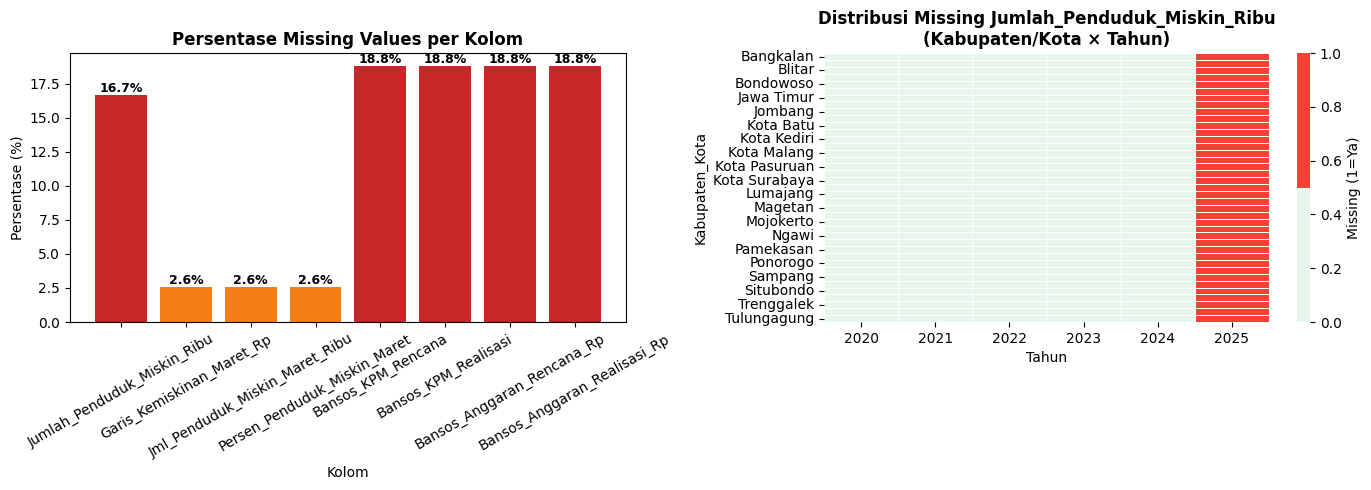


 Plot disimpan: plot_missing_values.png


In [ ]:
# IDENTIFIKASI MISSING VALUES

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
}).query('`Jumlah Missing` > 0')

print('=== RINGKASAN MISSING VALUES ===')
print(missing_df.to_string())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Baris terdampak    : {df[df.isnull().any(axis=1)].shape[0]} dari {len(df)}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart missing
cols_missing = missing_df.index
axes[0].bar(cols_missing, missing_df['Persentase (%)'],
            color=[WARNA_BAHAYA if x > 10 else WARNA_PERINGATAN for x in missing_df['Persentase (%)']])
axes[0].set_title('Persentase Missing Values per Kolom', fontweight='bold')
axes[0].set_ylabel('Persentase (%)')
axes[0].set_xlabel('Kolom')
axes[0].tick_params(axis='x', rotation=30)
for i, (col, val) in enumerate(zip(cols_missing, missing_df['Persentase (%)'])):
    axes[0].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Heatmap missing — Jumlah_Penduduk_Miskin_Ribu
miss_pivot = df.set_index(['Tahun','Kabupaten_Kota'])[['Jumlah_Penduduk_Miskin_Ribu']].isnull().astype(int)
miss_pivot = miss_pivot.reset_index().pivot_table(
    index='Kabupaten_Kota', columns='Tahun',
    values='Jumlah_Penduduk_Miskin_Ribu', aggfunc='sum')
sns.heatmap(miss_pivot, ax=axes[1], cmap=['#E8F5E9','#F44336'], linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'Missing (1=Ya)'})
axes[1].set_title('Distribusi Missing Jumlah_Penduduk_Miskin_Ribu\n(Kabupaten/Kota × Tahun)', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_missing_values.png', bbox_inches='tight')
plt.show()
print('\n Plot disimpan: plot_missing_values.png')

### ii. Outlier

=== RINGKASAN OUTLIER (Metode IQR) ===
                         Kolom           Q1           Q3   Batas Bawah   Batas Atas  Jumlah Outlier
                           IPM 7.096000e+01 7.715000e+01  6.167000e+01 8.644000e+01               0
   Jumlah_Penduduk_Miskin_Ribu 7.309000e+01 1.625700e+02 -6.114000e+01 2.968000e+02               5
        Rata_Rata_Lama_Sekolah 7.840000e+00 9.750000e+00  4.970000e+00 1.262000e+01               0
                    TPT_Persen 3.860000e+00 6.160000e+00  4.100000e-01 9.610000e+00               6
     Garis_Kemiskinan_Maret_Rp 3.948058e+05 5.245550e+05  2.001819e+05 7.191789e+05               3
Jml_Penduduk_Miskin_Maret_Ribu 7.009000e+01 1.532900e+02 -5.470000e+01 2.780800e+02               0
  Persen_Penduduk_Miskin_Maret 7.210000e+00 1.261000e+01 -8.900000e-01 2.070000e+01               6
            Bansos_KPM_Rencana 8.405375e+04 4.983738e+05 -5.374262e+05 1.119854e+06               3
          Bansos_KPM_Realisasi 8.440975e+04 4.830432e+05 -5.1

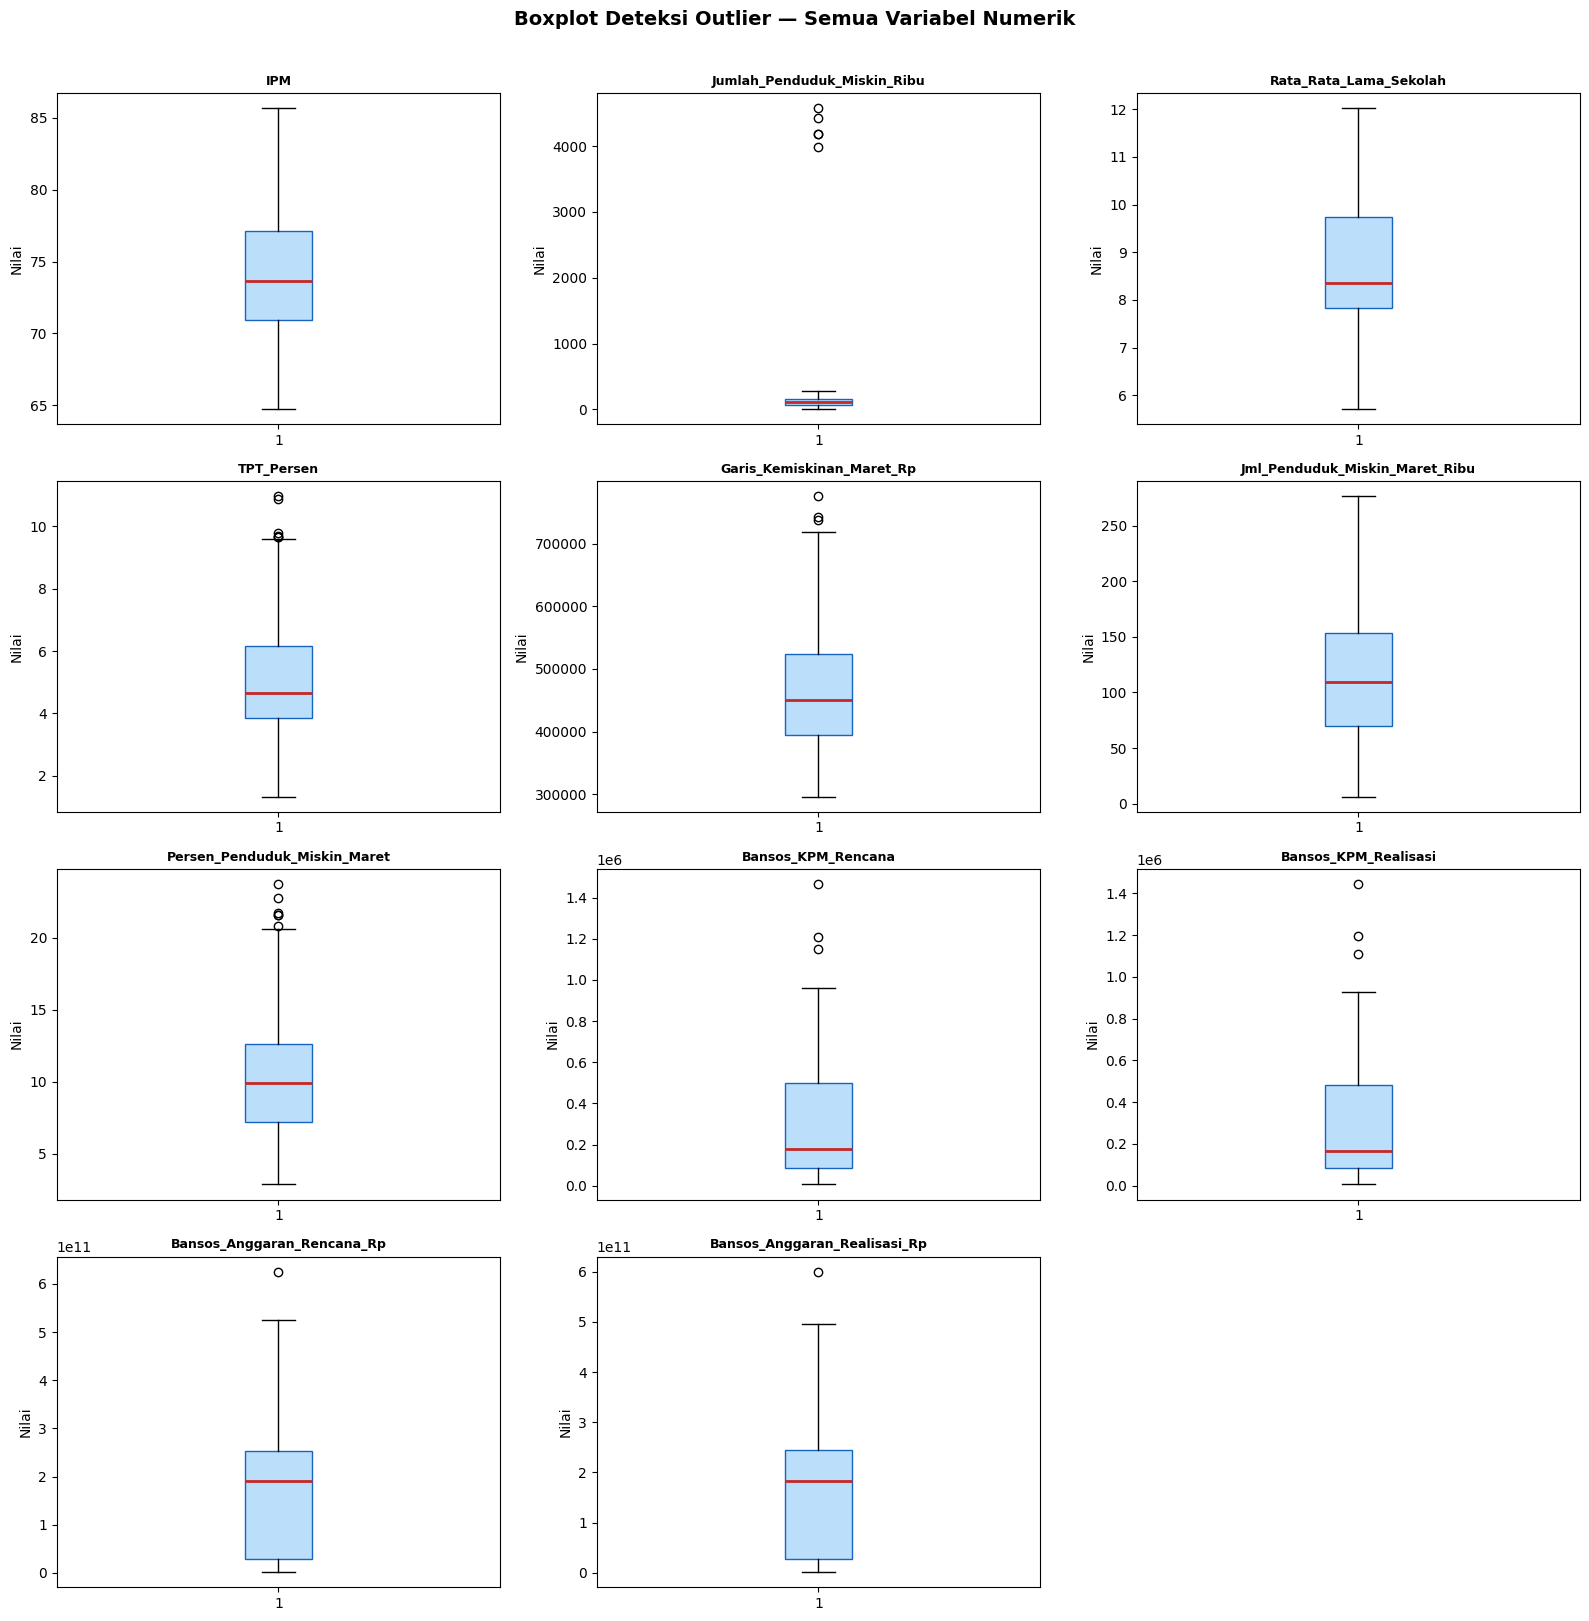

In [ ]:
# IDENTIFIKASI OUTLIER — Metode IQR
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'Tahun']

outlier_summary = []
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary.append({
        'Kolom': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'Batas Bawah': round(lower,2), 'Batas Atas': round(upper,2),
        'Jumlah Outlier': n_out
    })

out_df = pd.DataFrame(outlier_summary)
print('=== RINGKASAN OUTLIER (Metode IQR) ===')
print(out_df.to_string(index=False))

# Detail outlier TPT_Persen
col = 'TPT_Persen'
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
upper = Q3 + 1.5*(Q3-Q1)
lower_bound = Q1 - 1.5*(Q3-Q1)
print(f'\n Detail Outlier {col} (batas atas = {upper:.3f}):')
print(df[(df[col] < lower_bound) | (df[col] > upper)][['Tahun','Kabupaten_Kota',col]].to_string(index=False))

# Boxplot semua kolom numerik
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#BBDEFB', color=WARNA_UTAMA),
                    medianprops=dict(color=WARNA_BAHAYA, linewidth=2),
                    flierprops=dict(marker='o', color=WARNA_BAHAYA, markersize=6))
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Nilai')

# Sembunyikan axes kosong
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Deteksi Outlier — Semua Variabel Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_outlier_boxplot.png', bbox_inches='tight')
plt.show()

### iii. Inkonsistensi Data

=== CEK INKONSISTENSI DATA ===

1. Baris duplikat         : 0 baris 
2. IPM di luar 0–100      : 0 baris
3. Rata_Rata_Lama_Sekolah < 0 : 0 baris 
5. Persen_Miskin di luar 0–100: 0 baris
6. Bansos_Anggaran_Rencana < 0: 0 baris
7. Kelengkapan data       : 234/234 kombinasi Tahun × Kabupaten/Kota 

=== JUMLAH DATA PER KABUPATEN/KOTA ===
Kabupaten_Kota
Bangkalan           6
Banyuwangi          6
Blitar              6
Bojonegoro          6
Bondowoso           6
Gresik              6
Jawa Timur          6
Jember              6
Jombang             6
Kediri              6
Kota Batu           6
Kota Blitar         6
Kota Kediri         6
Kota Madiun         6
Kota Malang         6
Kota Mojokerto      6
Kota Pasuruan       6
Kota Probolinggo    6
Kota Surabaya       6
Lamongan            6
Lumajang            6
Madiun              6
Magetan             6
Malang              6
Mojokerto           6
Nganjuk             6
Ngawi               6
Pacitan             6
Pamekasan           6
Pasuruan   

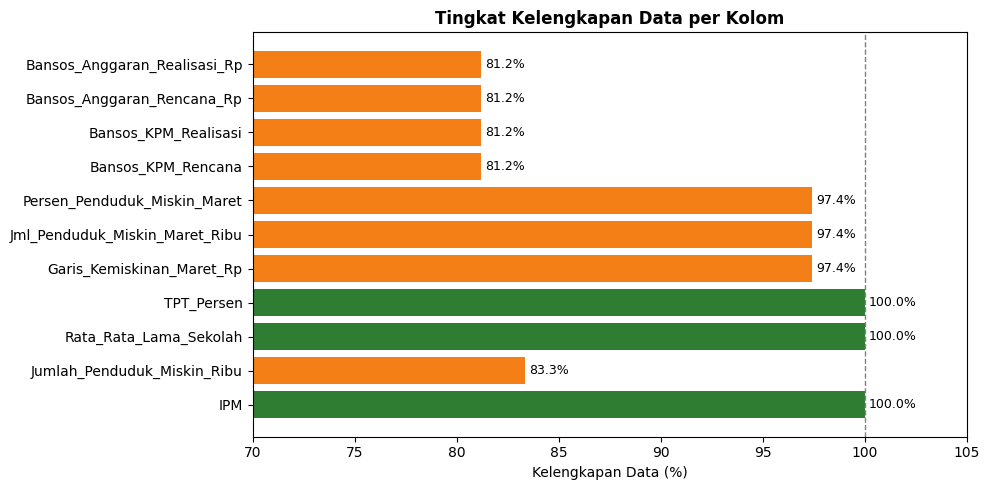

In [ ]:
# IDENTIFIKASI INKONSISTENSI DATA

print('=== CEK INKONSISTENSI DATA ===\n')

# 1. Duplikasi
dup = df.duplicated().sum()
print(f'1. Baris duplikat         : {dup} baris ')

# 2. Range / nilai tidak logis
ipm_invalid   = df[(df['IPM'] < 0) | (df['IPM'] > 100)].shape[0]
rls_invalid   = df[df['Rata_Rata_Lama_Sekolah'] < 0].shape[0]
pct_invalid   = df[(df['Persen_Penduduk_Miskin_Maret'] < 0) | (df['Persen_Penduduk_Miskin_Maret'] > 100)].shape[0]
bansos_neg    = df[df['Bansos_Anggaran_Rencana_Rp'] < 0].shape[0]
print(f'2. IPM di luar 0–100      : {ipm_invalid} baris')
print(f'3. Rata_Rata_Lama_Sekolah < 0 : {rls_invalid} baris ')
print(f'5. Persen_Miskin di luar 0–100: {pct_invalid} baris')
print(f'6. Bansos_Anggaran_Rencana < 0: {bansos_neg} baris')

# 3. Kelengkapan kombinasi Tahun × Kabupaten_Kota
expected_rows = df['Tahun'].nunique() * df['Kabupaten_Kota'].nunique()
actual_rows   = len(df)
print(f'7. Kelengkapan data       : {actual_rows}/{expected_rows} kombinasi Tahun × Kabupaten/Kota ')

# 4. Distribusi per kabupaten
print('\n=== JUMLAH DATA PER KABUPATEN/KOTA ===')
print(df['Kabupaten_Kota'].value_counts().to_string())

# Visualisasi completeness
completeness = (1 - df[numeric_cols].isnull().mean()) * 100
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(completeness.index, completeness.values,
               color=[WARNA_SUKSES if v == 100 else WARNA_PERINGATAN for v in completeness.values])
ax.axvline(100, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(70, 105)
ax.set_xlabel('Kelengkapan Data (%)')
ax.set_title('Tingkat Kelengkapan Data per Kolom', fontweight='bold')
for bar, val in zip(bars, completeness.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_Kelengkapan_Data.png', bbox_inches='tight')
plt.show()

# BAGIAN 2 — Data Cleaning

=== HASIL IMPUTASI ===
Missing setelah imputasi:
Jumlah_Penduduk_Miskin_Ribu       0
Garis_Kemiskinan_Maret_Rp         0
Jml_Penduduk_Miskin_Maret_Ribu    0
Persen_Penduduk_Miskin_Maret      0
Bansos_KPM_Rencana                0
Bansos_KPM_Realisasi              0
Bansos_Anggaran_Rencana_Rp        0
Bansos_Anggaran_Realisasi_Rp      0

--- Jumlah_Penduduk_Miskin_Ribu ---
  Mean  : 218.920 → 218.324
  Median: 115.180 → 115.330
  Std   : 663.027 → 660.538
--- Bansos_KPM_Rencana ---
  Mean  : 307034.247 → 306624.013
  Median: 180931.500 → 237180.000
  Std   : 280650.474 → 263066.392


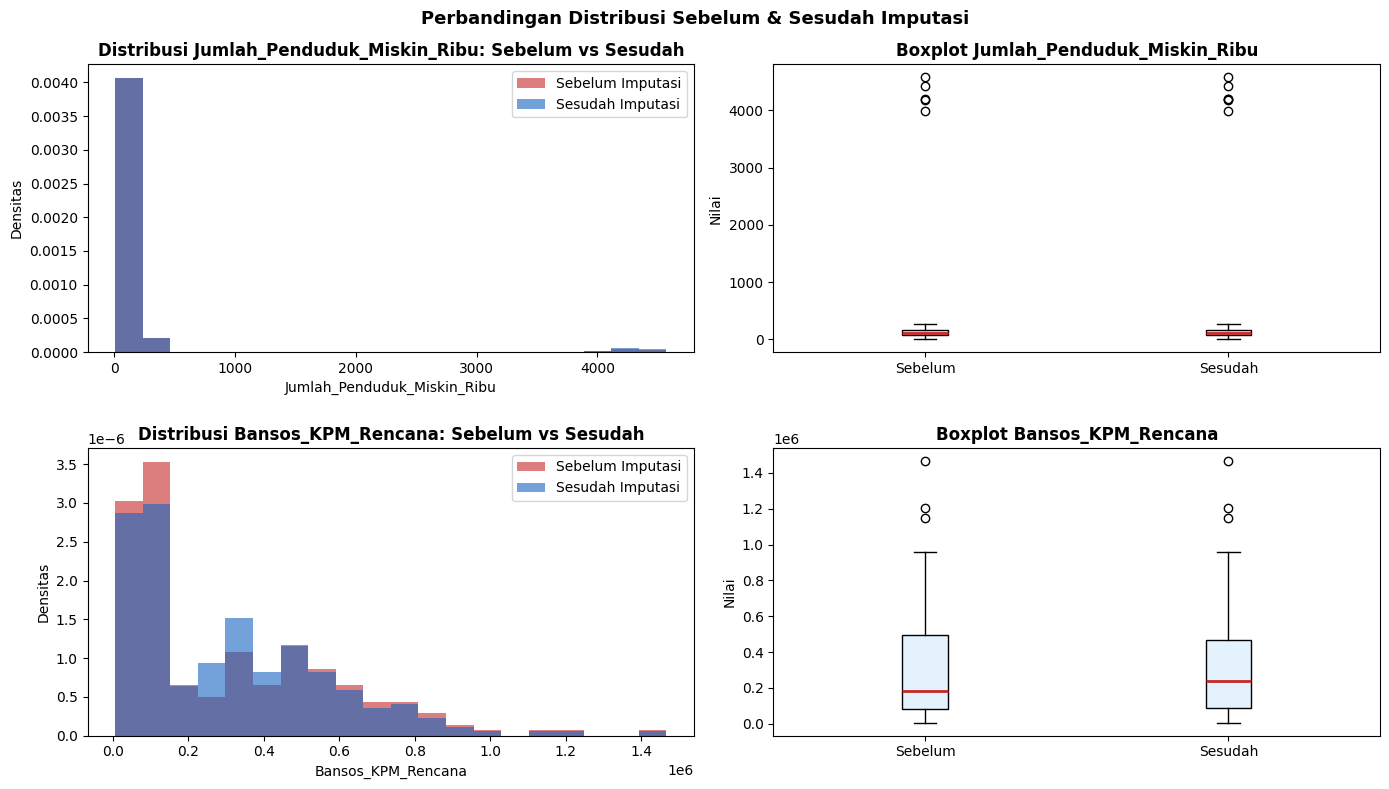

In [ ]:
# Imputasi Median per Kabupaten/Kota

df_clean = df.copy()

# Kolom yang memiliki missing values
impute_cols = [
    'Jumlah_Penduduk_Miskin_Ribu',
    'Garis_Kemiskinan_Maret_Rp',
    'Jml_Penduduk_Miskin_Maret_Ribu',
    'Persen_Penduduk_Miskin_Maret',
    'Bansos_KPM_Rencana',
    'Bansos_KPM_Realisasi',
    'Bansos_Anggaran_Rencana_Rp',
    'Bansos_Anggaran_Realisasi_Rp'
]

# Simpan statistik sebelum imputasi
stats_before = {col: df_clean[col].describe() for col in impute_cols}

# Imputasi dengan median per Kabupaten_Kota
for col in impute_cols:
    df_clean[col] = df_clean.groupby('Kabupaten_Kota')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Jika seluruh kabupaten kosong, gunakan median global
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Verifikasi
remaining_miss = df_clean[impute_cols].isnull().sum()
print('=== HASIL IMPUTASI ===')
print('Missing setelah imputasi:')
print(remaining_miss.to_string())
print()

# Perbandingan distribusi sebelum vs sesudah — tampilkan 2 kolom utama
show_cols = ['Jumlah_Penduduk_Miskin_Ribu', 'Bansos_KPM_Rencana']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(show_cols):
    # Histogram sebelum vs sesudah
    axes[i][0].hist(df[col].dropna(), bins=20, alpha=0.6, color=WARNA_BAHAYA,
                    density=True, label='Sebelum Imputasi')
    axes[i][0].hist(df_clean[col], bins=20, alpha=0.6, color=WARNA_UTAMA,
                    density=True, label='Sesudah Imputasi')
    axes[i][0].set_title(f'Distribusi {col}: Sebelum vs Sesudah', fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Densitas')
    axes[i][0].legend()

    # Boxplot
    data_bp = [df[col].dropna().values, df_clean[col].values]
    axes[i][1].boxplot(data_bp, patch_artist=True, labels=['Sebelum', 'Sesudah'],
                       boxprops=dict(facecolor='#E3F2FD'),
                       medianprops=dict(color=WARNA_BAHAYA, linewidth=2))
    axes[i][1].set_title(f'Boxplot {col}', fontweight='bold')
    axes[i][1].set_ylabel('Nilai')

    # Statistik
    stats_after = df_clean[col].describe()
    before_stat = df[col].describe()
    print(f'--- {col} ---')
    print(f'  Mean  : {before_stat["mean"]:.3f} → {stats_after["mean"]:.3f}')
    print(f'  Median: {before_stat["50%"]:.3f} → {stats_after["50%"]:.3f}')
    print(f'  Std   : {before_stat["std"]:.3f} → {stats_after["std"]:.3f}')

plt.suptitle('Perbandingan Distribusi Sebelum & Sesudah Imputasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_imputasi.png', bbox_inches='tight')
plt.show()

## Penanganan Outlier — Winsorize

=== WINSORIZING: TPT_Persen ===
Batas bawah (P5)  : 2.183
Batas atas  (P95) : 8.320
Sebelum — Mean: 4.9820 | Std: 1.8388
Sesudah — Mean: 4.9428 | Std: 1.6497
Perubahan Mean: 0.0392 (0.79%)


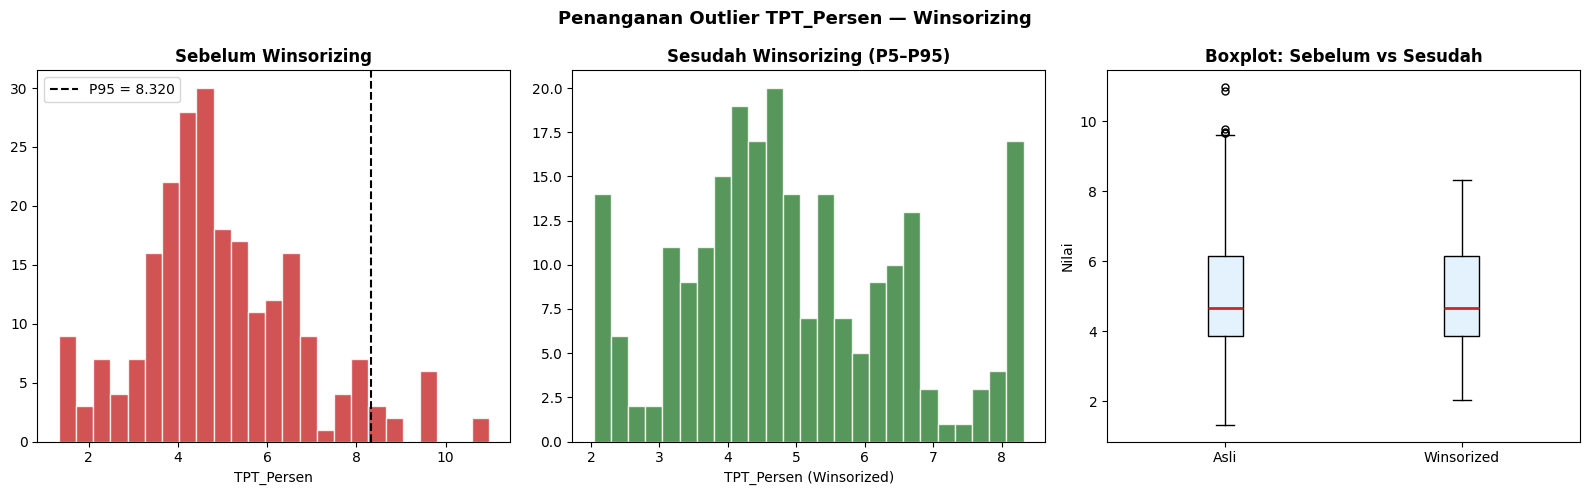

In [ ]:
col = 'TPT_Persen'

# Hitung batas
p5  = df_clean[col].quantile(0.05)
p95 = df_clean[col].quantile(0.95)
before_mean = df_clean[col].mean()
before_std  = df_clean[col].std()

print(f'=== WINSORIZING: {col} ===')
print(f'Batas bawah (P5)  : {p5:.3f}')
print(f'Batas atas  (P95) : {p95:.3f}')
print(f'Sebelum — Mean: {before_mean:.4f} | Std: {before_std:.4f}')

# Terapkan winsorizing
winsorized = winsorize(df_clean[col].values, limits=[0.05, 0.05])
df_clean[col + '_Win'] = winsorized

after_mean = df_clean[col + '_Win'].mean()
after_std  = df_clean[col + '_Win'].std()
print(f'Sesudah — Mean: {after_mean:.4f} | Std: {after_std:.4f}')
print(f'Perubahan Mean: {abs(before_mean - after_mean):.4f} ({abs(before_mean - after_mean)/before_mean*100:.2f}%)')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram sebelum
axes[0].hist(df_clean[col], bins=25, color=WARNA_BAHAYA, alpha=0.8, edgecolor='white')
axes[0].axvline(p95, color='black', linestyle='--', linewidth=1.5, label=f'P95 = {p95:.3f}')
axes[0].set_title('Sebelum Winsorizing', fontweight='bold')
axes[0].set_xlabel('TPT_Persen')
axes[0].legend()

# Histogram sesudah
axes[1].hist(df_clean[col + '_Win'], bins=25, color=WARNA_SUKSES, alpha=0.8, edgecolor='white')
axes[1].set_title('Sesudah Winsorizing (P5–P95)', fontweight='bold')
axes[1].set_xlabel('TPT_Persen (Winsorized)')

# Boxplot perbandingan
axes[2].boxplot([df_clean[col], df_clean[col + '_Win']],
                patch_artist=True,
                labels=['Asli', 'Winsorized'],
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color=WARNA_BAHAYA, linewidth=2),
                flierprops=dict(marker='o', color=WARNA_BAHAYA, markersize=5))
axes[2].set_title('Boxplot: Sebelum vs Sesudah', fontweight='bold')
axes[2].set_ylabel('Nilai')

plt.suptitle(f'Penanganan Outlier {col} — Winsorizing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_winsorizing.png', bbox_inches='tight')
plt.show()

# Ganti kolom asli dengan yang sudah diwinsorize
df_clean[col] = df_clean[col + '_Win']
df_clean.drop(columns=[col + '_Win'], inplace=True)

## Normalisasi — Min-Max Scaling

=== HASIL NORMALISASI MIN-MAX ===
                         Kolom     Min Asli     Max Asli     Range Baru
                           IPM 6.475000e+01 8.565000e+01 [0.000, 1.000]
   Jumlah_Penduduk_Miskin_Ribu 6.590000e+00 4.572730e+03 [0.000, 1.000]
        Rata_Rata_Lama_Sekolah 5.710000e+00 1.202000e+01 [0.000, 1.000]
                    TPT_Persen 2.040000e+00 8.320000e+00 [0.000, 1.000]
     Garis_Kemiskinan_Maret_Rp 2.962710e+05 7.755970e+05 [0.000, 1.000]
Jml_Penduduk_Miskin_Maret_Ribu 6.220000e+00 2.765800e+02 [0.000, 1.000]
  Persen_Penduduk_Miskin_Maret 2.860000e+00 2.376000e+01 [0.000, 1.000]
            Bansos_KPM_Rencana 6.333000e+03 1.466622e+06 [0.000, 1.000]
          Bansos_KPM_Realisasi 6.051000e+03 1.444896e+06 [0.000, 1.000]
    Bansos_Anggaran_Rencana_Rp 1.405800e+09 6.255404e+11 [0.000, 1.000]
  Bansos_Anggaran_Realisasi_Rp 1.229600e+09 6.002922e+11 [0.000, 1.000]


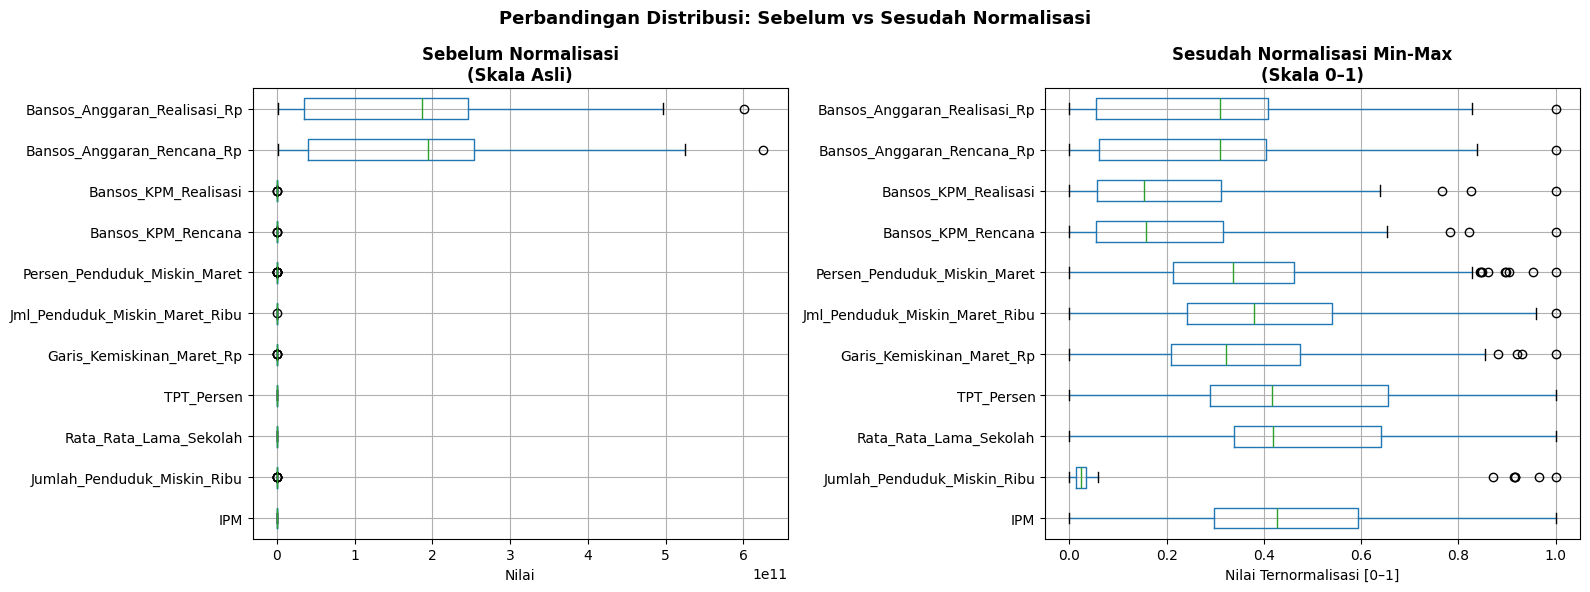

In [ ]:
cols_to_normalize = [
    'IPM',
    'Jumlah_Penduduk_Miskin_Ribu',
    'Rata_Rata_Lama_Sekolah',
    'TPT_Persen',
    'Garis_Kemiskinan_Maret_Rp',
    'Jml_Penduduk_Miskin_Maret_Ribu',
    'Persen_Penduduk_Miskin_Maret',
    'Bansos_KPM_Rencana',
    'Bansos_KPM_Realisasi',
    'Bansos_Anggaran_Rencana_Rp',
    'Bansos_Anggaran_Realisasi_Rp'
]

df_normalized = df_clean.copy()

normalization_info = []
for col in cols_to_normalize:
    min_val = df_normalized[col].min()
    max_val = df_normalized[col].max()
    df_normalized[col + '_Norm'] = (df_normalized[col] - min_val) / (max_val - min_val)
    normalization_info.append({'Kolom': col, 'Min Asli': round(min_val,4),
                                'Max Asli': round(max_val,4),
                                'Range Baru': '[0.000, 1.000]'})

norm_df = pd.DataFrame(normalization_info)
print('=== HASIL NORMALISASI MIN-MAX ===')
print(norm_df.to_string(index=False))

# Visualisasi: sebelum vs sesudah normalisasi
norm_cols = [c + '_Norm' for c in cols_to_normalize]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum normalisasi
df_clean[cols_to_normalize].boxplot(ax=axes[0], vert=False)
axes[0].set_title('Sebelum Normalisasi\n(Skala Asli)', fontweight='bold')
axes[0].set_xlabel('Nilai')

# Sesudah normalisasi
df_normalized[norm_cols].rename(columns=lambda c: c.replace('_Norm',''))\
    .boxplot(ax=axes[1], vert=False)
axes[1].set_title('Sesudah Normalisasi Min-Max\n(Skala 0–1)', fontweight='bold')
axes[1].set_xlabel('Nilai Ternormalisasi [0–1]')

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Normalisasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_normalisasi.png', bbox_inches='tight')
plt.show()

# Ekspor Dataset


 Dataset Asli   : 234 baris × 14 kolom
Dataset Bersih : 234 baris × 14 kolom
Tidak ada baris dihapus 

--- Status Missing Values ---
Total missing values tersisa: 0 

--- Statistik Deskriptif Dataset Bersih ---
          IPM  Jumlah_Penduduk_Miskin_Ribu  TPT_Persen  Persen_Penduduk_Miskin_Maret
count  234.00                       234.00      234.00                        234.00
mean    74.39                       218.32        4.94                         10.36
std      4.74                       660.54        1.65                          4.33
min     64.75                         6.59        2.04                          2.86
25%     70.96                        73.06        3.86                          7.31
50%     73.66                       115.33        4.66                          9.89
75%     77.15                       160.77        6.16                         12.50
max     85.65                      4572.73        8.32                         23.76


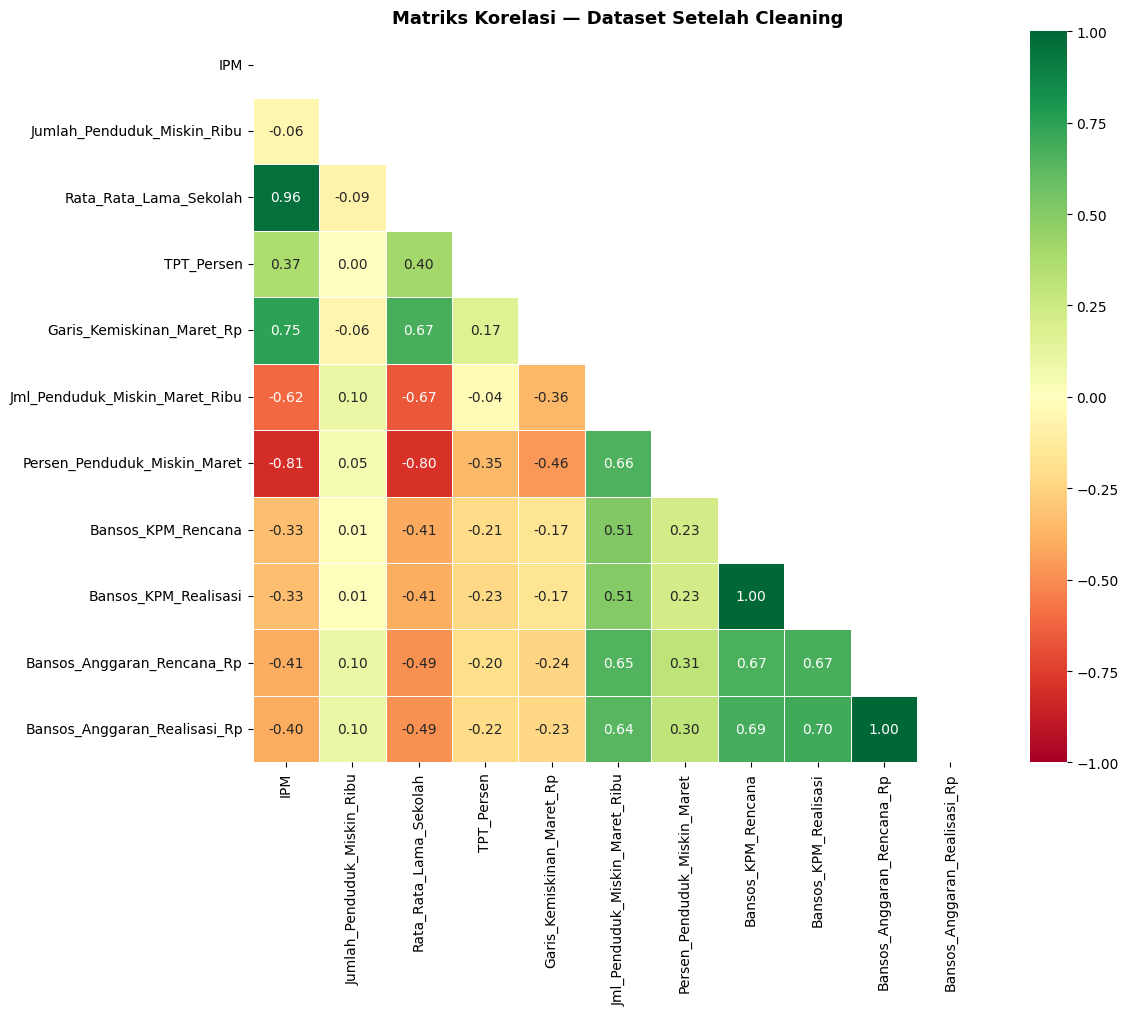

In [ ]:
# VERIFIKASI KUALITAS DATA AKHIR

print(f'\n Dataset Asli   : {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Dataset Bersih : {df_clean.shape[0]} baris × {df_clean.shape[1]} kolom')
print(f'Tidak ada baris dihapus ')

print('\n--- Status Missing Values ---')
remaining = df_clean.isnull().sum().sum()
print(f'Total missing values tersisa: {remaining} ')

print('\n--- Statistik Deskriptif Dataset Bersih ---')
print(df_clean[['IPM','Jumlah_Penduduk_Miskin_Ribu','TPT_Persen','Persen_Penduduk_Miskin_Maret']].describe().round(2).to_string())

# Korelasi untuk pemahaman awal
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_clean[cols_to_normalize].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
ax.set_title('Matriks Korelasi — Dataset Setelah Cleaning', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_korelasi.png', bbox_inches='tight')
plt.show()

In [ ]:
# EKSPOR FILE
from openpyxl import load_workbook

# Konversi kolom Rupiah ke integer agar tidak muncul scientific notation di Excel/Power BI
rp_cols = ['Garis_Kemiskinan_Maret_Rp', 'Bansos_Anggaran_Rencana_Rp', 'Bansos_Anggaran_Realisasi_Rp']
for col in rp_cols:
    df_clean[col] = df_clean[col].round(0).astype('Int64')

# Simpan ke Excel
output_cleaned = 'dataset_jawatimur_CLEANED.xlsx'
df_clean.to_excel(output_cleaned, index=False, engine='openpyxl')

# Format sel kolom Rp sebagai angka biasa
wb = load_workbook(output_cleaned)
ws = wb.active
header = [cell.value for cell in ws[1]]
for col_name in rp_cols:
    if col_name in header:
        col_idx = header.index(col_name) + 1
        for row in ws.iter_rows(min_row=2, min_col=col_idx, max_col=col_idx):
            for cell in row:
                if cell.value is not None:
                    cell.number_format = '#,##0'
wb.save(output_cleaned)

print(f'File disimpan: {output_cleaned}')
files.download(output_cleaned)

File disimpan: dataset_jawatimur_CLEANED.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>